![cyber_photo](cyber_photo.jpg)

Cyber threats are a growing concern for organizations worldwide. These threats take many forms, including malware, phishing, and denial-of-service (DOS) attacks, compromising sensitive information and disrupting operations. The increasing sophistication and frequency of these attacks make it imperative for organizations to adopt advanced security measures. Traditional threat detection methods often fall short due to their inability to adapt to new and evolving threats. This is where deep learning models come into play.

Deep learning models can analyze vast amounts of data and identify patterns that may not be immediately obvious to human analysts. By leveraging these models, organizations can proactively detect and mitigate cyber threats, safeguarding their sensitive information and ensuring operational continuity.

As a cybersecurity analyst, you identify and mitigate these threats. In this project, you will design and implement a deep learning model to detect cyber threats. The BETH dataset simulates real-world logs, providing a rich source of information for training and testing your model. The data has already undergone preprocessing, and we have a target label, `sus_label`, indicating whether an event is malicious (1) or benign (0).

By successfully developing this model, you will contribute to enhancing cybersecurity measures and protecting organizations from potentially devastating cyber attacks.


### The Data

| Column     | Description              |
|------------|--------------------------|
|`processId`|The unique identifier for the process that generated the event - int64 |
|`threadId`|ID for the thread spawning the log - int64|
|`parentProcessId`|Label for the process spawning this log - int64|
|`userId`|ID of user spawning the log|Numerical - int64|
|`mountNamespace`|Mounting restrictions the process log works within - int64|
|`argsNum`|Number of arguments passed to the event - int64|
|`returnValue`|Value returned from the event log (usually 0) - int64|
|`sus_label`|Binary label as suspicous event (1 is suspicious, 0 is not) - int64|

More information on the dataset: [BETH dataset](accreditation.md)

In [14]:
# Import required libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as functional
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from torchmetrics import Accuracy
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.metrics import accuracy_score  # uncomment to use sklearn

In [4]:
# remove warnings
import warnings
warnings.filterwarnings("ignore")

In [5]:
# Load preprocessed data
train_df = pd.read_csv('labelled_train.csv')
test_df = pd.read_csv('labelled_test.csv')
val_df = pd.read_csv('labelled_validation.csv')

# View the first 5 rows of training set
train_df.head()

,processId,threadId,parentProcessId,userId,mountNamespace,argsNum,returnValue,sus_label
0,381,7337,1,100,4026532231,5,0,1
1,381,7337,1,100,4026532231,1,0,1
2,381,7337,1,100,4026532231,0,0,1
3,7347,7347,7341,0,4026531840,2,-2,1
4,7347,7347,7341,0,4026531840,4,0,1


In [ ]:
train_df.plot.

In [6]:
X = train_df.drop('sus_label', axis=1).values
y = train_df['sus_label'].values

In [7]:
# Standardize the features
X = StandardScaler().fit_transform(X)

In [8]:
X = torch.FloatTensor(X)
y = torch.FloatTensor(y)

dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

In [9]:
import mpmath
print(mpmath.__file__)

/usr/lib/python3.14/site-packages/mpmath/__init__.py


In [12]:
model = nn.Sequential(
    nn.Linear(X.shape[1], 4),
    nn.ReLU(),
    nn.Linear(4, 2),
    nn.ReLU(),
    nn.Linear(2, 1),
    nn.Sigmoid()
)

criterion = nn.MSELoss()

optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

num_epochs = 5

In [13]:
training_loss = []
for epoch in range(num_epochs):
    for batch_idx, (X, y) in enumerate(dataloader):
        model.train()
        
        optimizer.zero_grad()
        pred = model(X)
        
        loss = criterion(pred,y)
        loss.backward()
        optimizer.step()
    training_loss.append(loss.item())
    print(f'Epoch: {epoch}, Batch: {batch_idx}, Loss: {loss.item()}')
print("training loss per epoch: ", sum(training_loss)/(num_epochs * len(dataloader)))

Epoch: 0, Batch: 1490, Loss: 0.02686932310461998
Epoch: 1, Batch: 1490, Loss: 0.011505678296089172
Epoch: 2, Batch: 1490, Loss: 0.007366626989096403
Epoch: 3, Batch: 1490, Loss: 0.005317539907991886
Epoch: 4, Batch: 1490, Loss: 0.004158351570367813
training loss per epoch:  7.406776642275688e-06


In [15]:
# validation loader
X_val = val_df.drop('sus_label', axis=1).values
y_val = val_df['sus_label'].values

X_val = StandardScaler().fit_transform(X_val)
X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)

val_dataset = TensorDataset(X_val, y_val)
validationloader = DataLoader(val_dataset, batch_size=512, shuffle=False)

In [16]:
# Set the model to evaluation mode
model.eval()
validation_loss = []

with torch.no_grad():
  for features, labels in validationloader:
      outputs = model(features)
      loss = criterion(outputs, labels)
      # Sum the current loss to the validation_loss variable
      validation_loss.append(loss.item())

# Calculate the mean loss value
validation_loss_epoch = sum(validation_loss)/len(validationloader)
print(validation_loss_epoch)

# Set the model back to training mode
model.train()

0.00788108758074609


Sequential(
  (0): Linear(in_features=7, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=2, bias=True)
  (3): ReLU()
  (4): Linear(in_features=2, out_features=1, bias=True)
  (5): Sigmoid()
)

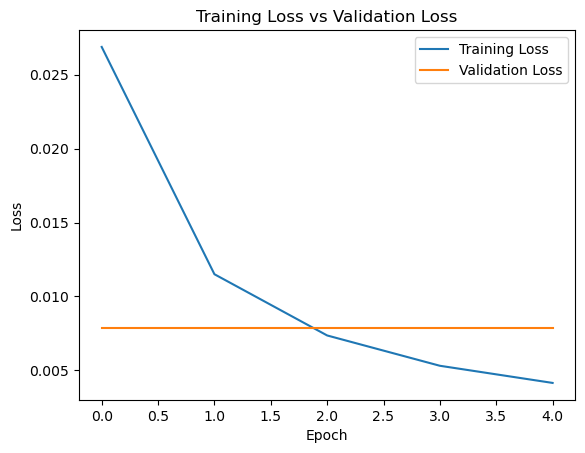

In [17]:
#plot train loss vs validation loss
plt.plot(training_loss, label='Training Loss')
plt.plot([validation_loss_epoch]*len(training_loss), label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()
plt.show()

In [19]:
# Create accuracy metric
metric = Accuracy(task="multiclass", num_classes=3)
for features, labels in dataloader:
    outputs = model(features)
    
    # Convert model outputs (logits/probabilities) to predicted class indices
    preds = outputs.argmax(dim=1)
    
    # Calculate accuracy over the batch
    metric.update(preds, labels.int())
    
# Calculate accuracy over the whole epoch
val_accuracy = float(metric.compute())
print(f"Accuracy on all data: {val_accuracy}")

# Reset metric for the next epoch
metric.reset()

Accuracy on all data: 0.9983371496200562
